In [17]:
import numpy as np
import matplotlib.pyplot as plt
from lib_algebra import power_mth, inv_power_mth, QR_eigensolver, QR_dec, back_subst
import lib_equations
import lib_fitting

A = [[ 4.+0.j -0.-1.j  2.+0.j]
 [ 0.+1.j  2.+0.j  2.+7.j]
 [ 2.+0.j  2.-7.j -2.+0.j]]

MAX eig_val = (8.45187689959674-7.549516567451064e-15j)
eig_vect = [0.63491092-0.59342626j 1.18122253+0.91110263j 0.95772132-0.73031907j]

min eig_val = (3.18960274704806-1.56652584398598e-16j)
eig_vect = [ 1.0635115 -0.05265637j -0.11242584-0.43133196j -0.21526741-0.03487663j]

Lambdas = [ 8.4518769 -2.37823613e-16j -7.64147965+6.82884752e-16j
  3.18960275+1.72542130e-17j]
Vects =
 [[ 0.41284464+1.93934760e-17j -0.03061002+8.39647584e-02j
   0.90626703-1.58842009e-02j]
 [ 0.11440717+6.99367493e-01j -0.59205186+5.74658084e-02j
  -0.08392438-3.70033888e-01j]
 [ 0.56928302+5.72035837e-02j  0.14944007-7.84762946e-01j
  -0.18220121-3.55259355e-02j]]


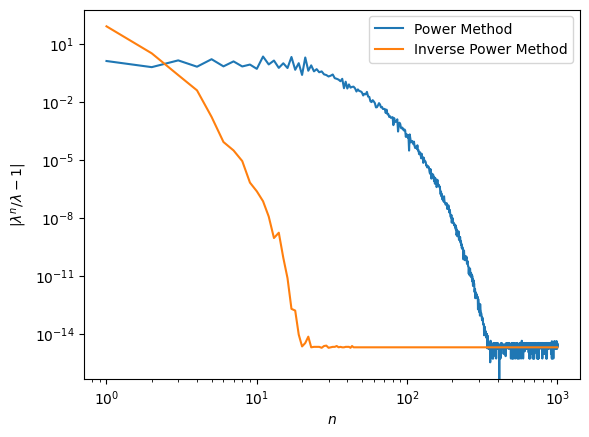

In [27]:
A_test = np.array([
    [4,   -1j,        2],
    [1j,   2,   2 + 7j],
    [2,  2 - 7j,     -2]
], dtype=complex)



print('A =', A_test)

print()
maxeig_val, eig_vect = power_mth(A_test)
print('MAX eig_val =', maxeig_val)
print('eig_vect =', eig_vect)

print()
mineig_val, eig_vect = inv_power_mth(A_test)
print('min eig_val =', mineig_val)
print('eig_vect =', eig_vect)

print()
eigval, eigvect = QR_eigensolver(A_test)
print('Lambdas =', eigval)
print('Vects =\n', eigvect)



def power_n(A_in, n):
    A = np.copy(A_in)
    x_0 = np.random.rand(len(A))    # choice of a random vector
    y = x_0 / np.sqrt(x_0@x_0)      # the vector is chosen normalised
    lamb = 1

    for i in range(n):
        y = A @ y
        y = y / np.sqrt(y@y)
        lamb = y.T @ A @ y     # y is normalised --> lamb1 is the next eigval

    return lamb


def inv_power_n(A_in, n):
    A = np.copy(A_in)
    Q, R = QR_dec(A)
    x_k = np.random.rand(len(A))    
    x_k = x_k / np.sqrt(x_k@x_k)      
    lamb = 0
    for i in range(n):
        d = Q.conj().T @ x_k
        x_k1 = back_subst(R, d)
        num = x_k.conj().T @ x_k
        den = x_k.conj().T @ x_k1
        x_k1 = x_k1 / np.sqrt(x_k1@x_k1)
        x_k = x_k1
        lamb = num / den  

    return lamb

xcoo = np.arange(1, 1000)
arr_pow = []
arr_inv = []
for i in xcoo:
    arr_pow.append(abs(power_n(A_test, i) / maxeig_val - 1))
    arr_inv.append(abs(inv_power_n(A_test, i) / mineig_val - 1))

plt.plot(xcoo, arr_pow, label=r'Power Method')
plt.plot(xcoo, arr_inv, label=r'Inverse Power Method')
plt.xlabel(r'$n$')
plt.ylabel(r'$|\lambda^n / \lambda - 1|$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()